# Module 3.2 - Data Visualization & Exploratory Data Analysis
### NASCAR Sponsorship Visibility - Week 4 (visualization + hypotheses)

Turns the correlation findings into publication-quality charts, then formulates testable
hypotheses for the scoring model.

**Sponsors:** FedEx, NAPA Auto Parts, McDonald's, Love's Travel Stops, **Season:** 2024 Cup Series (36 races), 144 rows.

**Data caveats carried from Module 3.1 (they shape every chart below):**
- `reddit_mentions` is a **Google Trends** search-interest proxy (Reddit API returned 403).
- `reddit_mentions` and `youtube_total_views` are **race-level** - identical for all four
  sponsors within a race. Only `news_total_mentions` varies by sponsor.
- Consequence: sponsor-to-sponsor differences appear almost entirely through news; seasonal
  patterns are shared across sponsors (they are race-driven).

Charts are saved to `output/figures/`.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

FIG = '../output/figures'
os.makedirs(FIG, exist_ok=True)

df = pd.read_csv('../data/processed/master_dataset.csv').rename(columns={
    'sponsor': 'Sponsor', 'race_name': 'Race', 'race_number': 'Race_Number',
    'finish_position': 'Finish_Position', 'laps_led': 'Laps_Led',
    'reddit_mentions': 'Reddit_Mentions', 'youtube_total_views': 'YouTube_Views',
    'news_total_mentions': 'News_Mentions',
})
sponsors = df['Sponsor'].unique()
colors = sns.color_palette('husl', len(sponsors))
print(f'Loaded {len(df)} rows, {len(sponsors)} sponsors, {df["Race_Number"].nunique()} races')

Loaded 144 rows, 4 sponsors, 36 races


---
## Step 3, Scatter Plots

### 3.1 Primary scatter - Finish Position vs. Reddit Mentions (with trend line & R²)
The core question: does better on-track performance drive more social buzz? *(x-axis is
inverted so better finishes sit on the left.)*

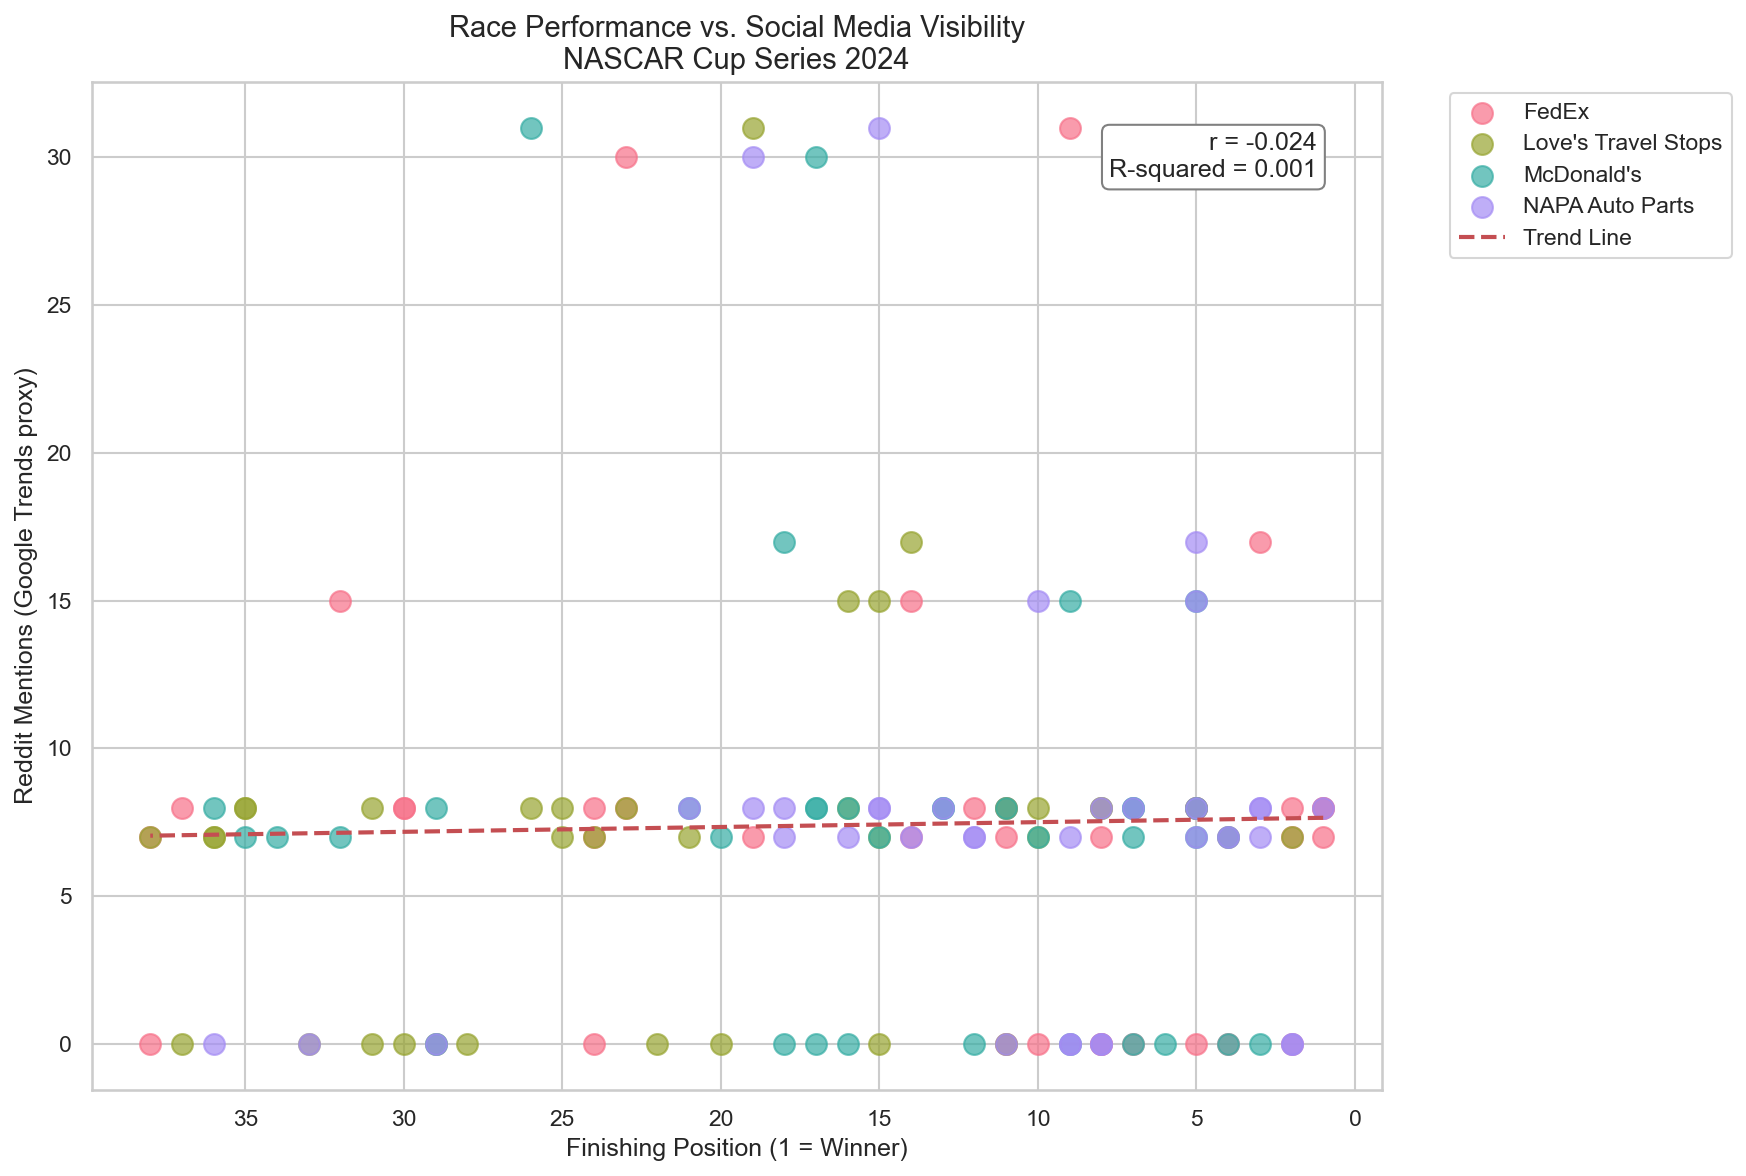

r = -0.024 (near zero - the expected negative trend is absent; see caveats)


In [2]:
fig, ax = plt.subplots(figsize=(12, 8))
for i, sponsor in enumerate(sponsors):
    sd = df[df['Sponsor'] == sponsor]
    ax.scatter(sd['Finish_Position'], sd['Reddit_Mentions'], label=sponsor,
               alpha=0.7, s=100, color=colors[i])

z = np.polyfit(df['Finish_Position'], df['Reddit_Mentions'], 1)
p = np.poly1d(z)
xl = np.linspace(df['Finish_Position'].min(), df['Finish_Position'].max(), 100)
ax.plot(xl, p(xl), 'r--', linewidth=2, label='Trend Line')

r = df['Finish_Position'].corr(df['Reddit_Mentions'])
ax.annotate(f'r = {r:.3f}\nR-squared = {r**2:.3f}', xy=(0.95, 0.95),
            xycoords='axes fraction', fontsize=12, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray'))

ax.set_xlabel('Finishing Position (1 = Winner)')
ax.set_ylabel('Reddit Mentions (Google Trends proxy)')
ax.set_title('Race Performance vs. Social Media Visibility\nNASCAR Cup Series 2024')
ax.legend(loc='upper right', bbox_to_anchor=(1.28, 1))
ax.invert_xaxis()
plt.tight_layout()
plt.savefig(f'{FIG}/scatter_finish_vs_reddit.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'r = {r:.3f} (near zero - the expected negative trend is absent; see caveats)')

> Points fall in vertical bands because Reddit is race-level (all four sponsors share one
> value per race). The trend line is essentially flat - consistent with the Module 3.1
> correlation of r ≈ -0.02.

### 3.2 Scatter grid - all key metric pairs

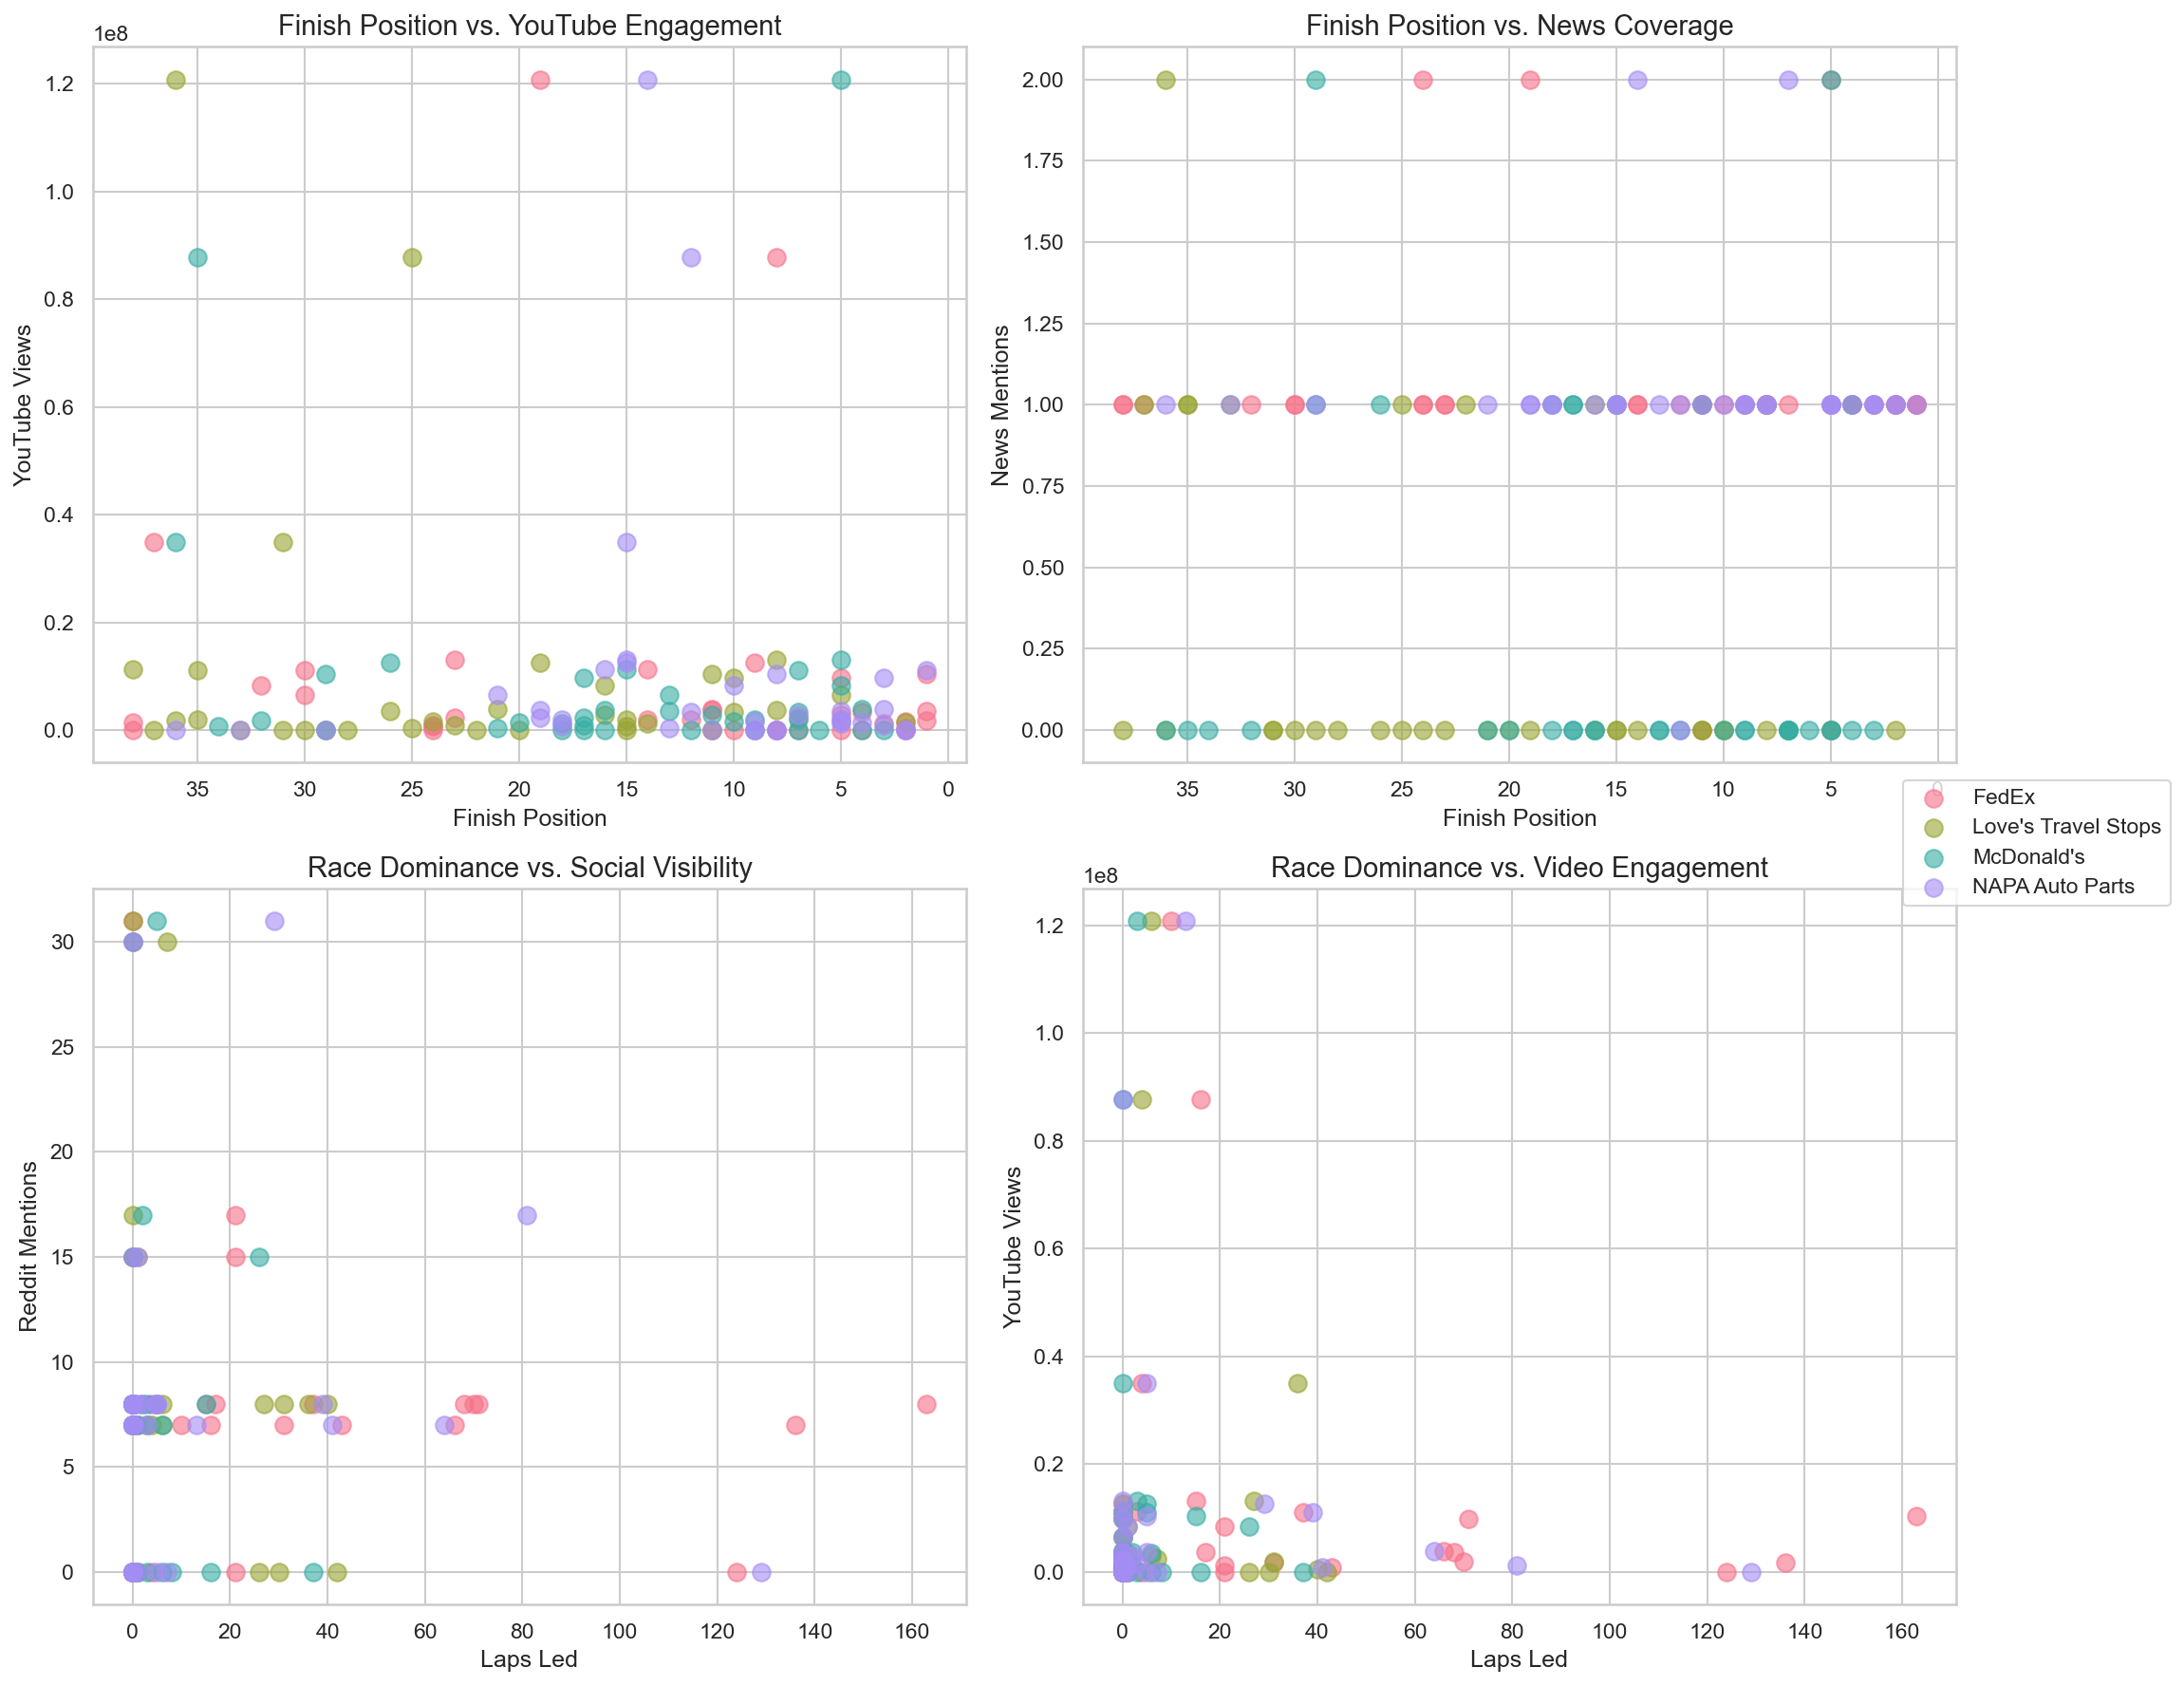

Saved scatter_grid_all_metrics.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
pairs = [
    (axes[0,0], 'Finish_Position', 'YouTube_Views', 'Finish Position vs. YouTube Engagement', True),
    (axes[0,1], 'Finish_Position', 'News_Mentions', 'Finish Position vs. News Coverage', True),
    (axes[1,0], 'Laps_Led', 'Reddit_Mentions', 'Race Dominance vs. Social Visibility', False),
    (axes[1,1], 'Laps_Led', 'YouTube_Views', 'Race Dominance vs. Video Engagement', False),
]
for ax, xcol, ycol, title, invert in pairs:
    for i, sponsor in enumerate(sponsors):
        sd = df[df['Sponsor'] == sponsor]
        ax.scatter(sd[xcol], sd[ycol], alpha=0.6, s=80, color=colors[i], label=sponsor)
    ax.set_xlabel(xcol.replace('_', ' '))
    ax.set_ylabel(ycol.replace('_', ' '))
    ax.set_title(title)
    if invert:
        ax.invert_xaxis()
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.10, 0.5))
plt.tight_layout()
plt.savefig(f'{FIG}/scatter_grid_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved scatter_grid_all_metrics.png')

### 3.3 Regression-annotated scatter (Finish Position vs. Reddit) with full statistics

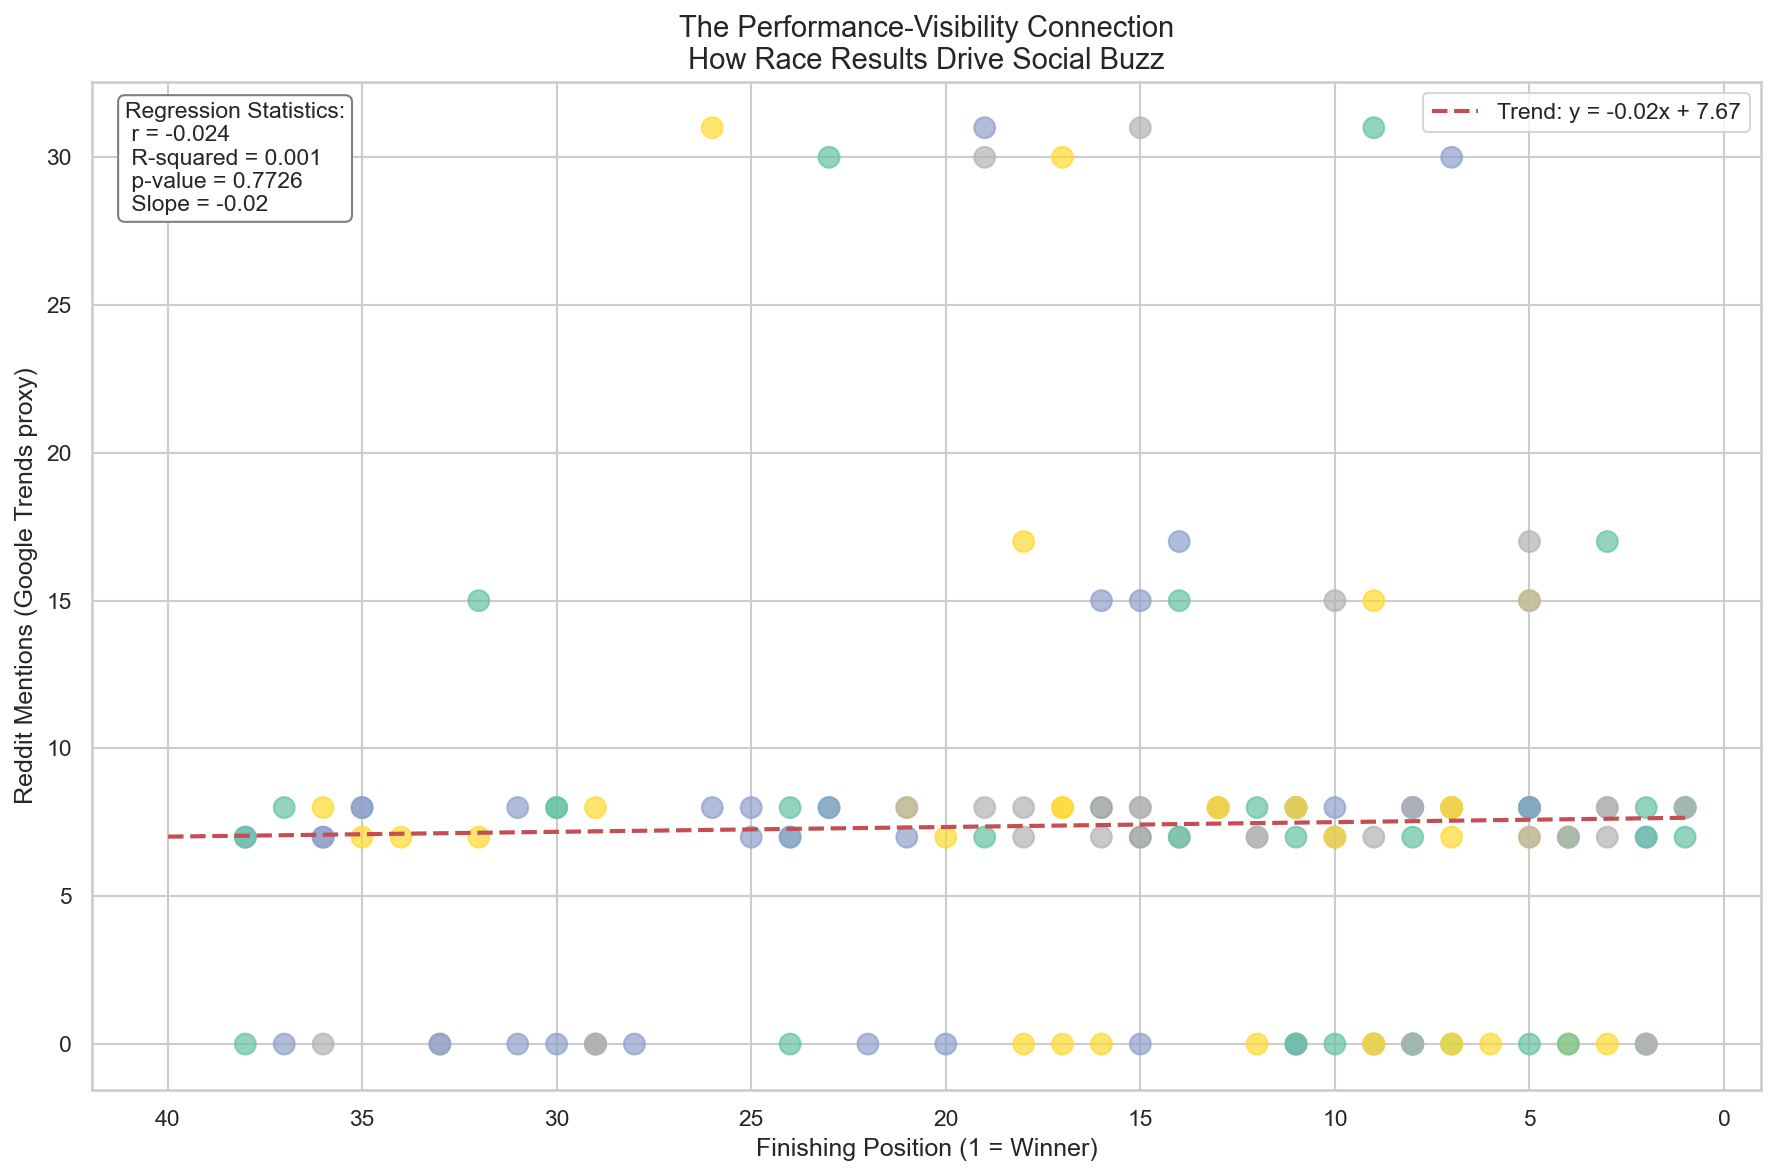

r=-0.024 R2=0.001 p=0.7726 slope=-0.02


In [4]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(df['Finish_Position'], df['Reddit_Mentions'],
           c=df['Sponsor'].astype('category').cat.codes, cmap='Set2', alpha=0.7, s=100)

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df['Finish_Position'], df['Reddit_Mentions'])
xl = np.linspace(1, 40, 100)
ax.plot(xl, slope*xl + intercept, 'r--', linewidth=2,
        label=f'Trend: y = {slope:.2f}x + {intercept:.2f}')

txt = (f'Regression Statistics:\n r = {r_value:.3f}\n R-squared = {r_value**2:.3f}\n'
       f' p-value = {p_value:.4f}\n Slope = {slope:.2f}')
ax.annotate(txt, xy=(0.02, 0.98), xycoords='axes fraction', fontsize=11, va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray'))
ax.set_xlabel('Finishing Position (1 = Winner)')
ax.set_ylabel('Reddit Mentions (Google Trends proxy)')
ax.set_title('The Performance-Visibility Connection\nHow Race Results Drive Social Buzz')
ax.invert_xaxis()
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'{FIG}/scatter_with_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'r={r_value:.3f} R2={r_value**2:.3f} p={p_value:.4f} slope={slope:.2f}')

---
## Step 4, Sponsor Comparison Visualizations

### 4.1 Composite visibility score by sponsor

We build a 0-100 composite = 0.4, Reddit + 0.3, YouTube + 0.3, News (each min-max normalized).
**Adaptation & caveat:** Reddit and YouTube are identical across sponsors, so their min-max
range is zero - normalizing them would divide by zero. We set a constant channel to a neutral
0.5, so *sponsor differentiation here comes entirely from news coverage.*

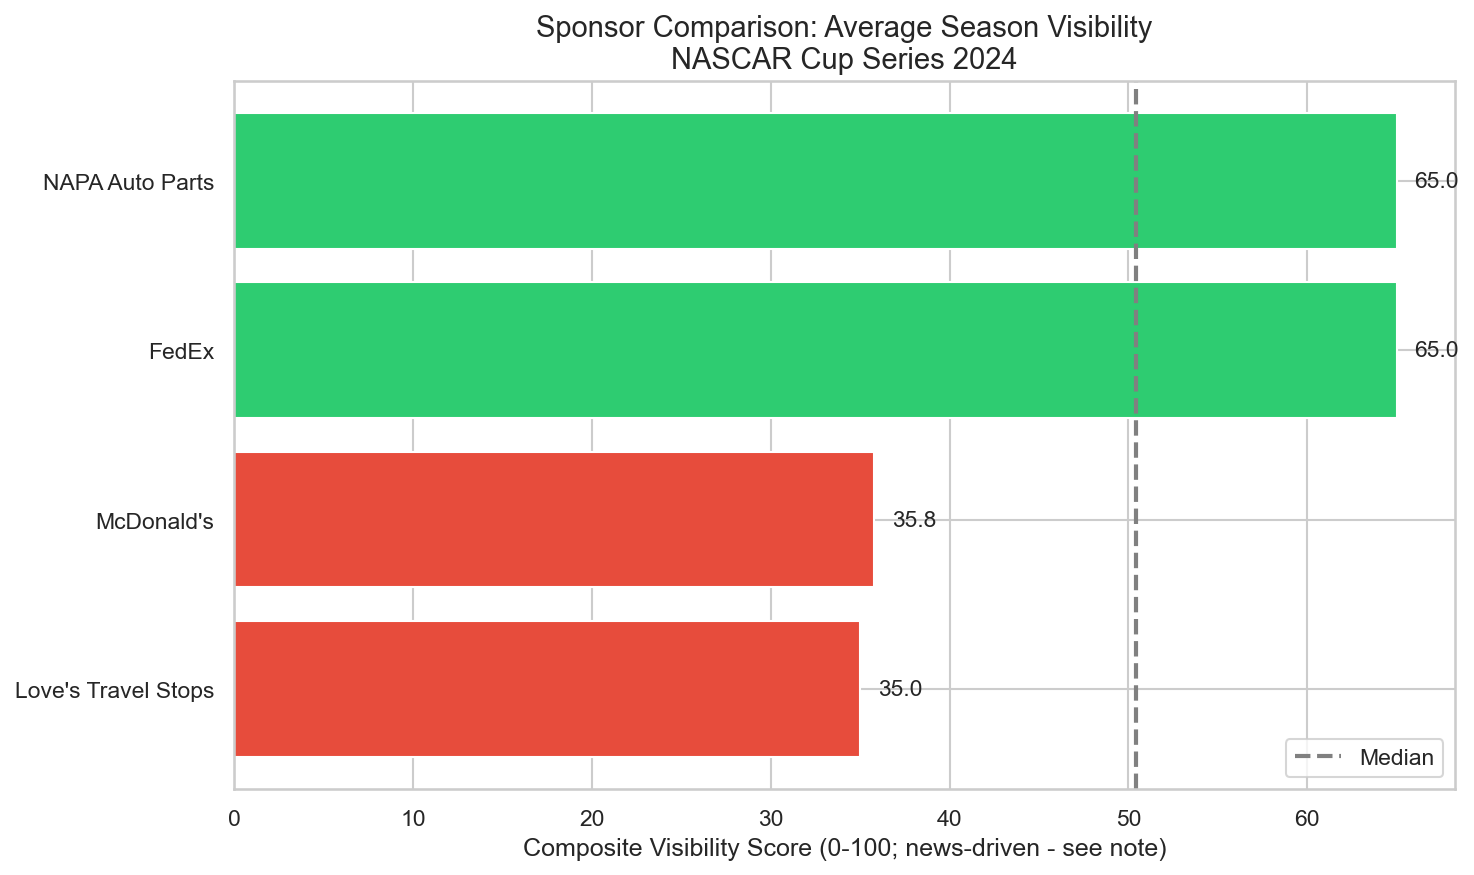

                     News_Mentions  Visibility_Score
Sponsor                                             
Love's Travel Stops           0.31              35.0
McDonald's                    0.33              35.8
FedEx                         1.03              65.0
NAPA Auto Parts               1.03              65.0


In [5]:
def norm(s):
    rng = s.max() - s.min()
    return pd.Series(0.5, index=s.index) if rng == 0 else (s - s.min()) / rng

sponsor_summary = df.groupby('Sponsor').agg({
    'Reddit_Mentions': 'mean', 'YouTube_Views': 'mean',
    'News_Mentions': 'mean', 'Finish_Position': 'mean'}).round(2)
sponsor_summary['Reddit_N'] = norm(sponsor_summary['Reddit_Mentions'])
sponsor_summary['YouTube_N'] = norm(sponsor_summary['YouTube_Views'])
sponsor_summary['News_N'] = norm(sponsor_summary['News_Mentions'])
sponsor_summary['Visibility_Score'] = (
    (sponsor_summary['Reddit_N']*0.4 + sponsor_summary['YouTube_N']*0.3
     + sponsor_summary['News_N']*0.3) * 100).round(1)
sponsor_summary = sponsor_summary.sort_values('Visibility_Score')

fig, ax = plt.subplots(figsize=(10, 6))
med = sponsor_summary['Visibility_Score'].median()
bar_colors = ['#2ecc71' if v >= med else '#e74c3c' for v in sponsor_summary['Visibility_Score']]
bars = ax.barh(sponsor_summary.index, sponsor_summary['Visibility_Score'], color=bar_colors)
for bar, v in zip(bars, sponsor_summary['Visibility_Score']):
    ax.text(v + 1, bar.get_y() + bar.get_height()/2, f'{v:.1f}', va='center', fontsize=11)
ax.axvline(med, color='gray', linestyle='--', linewidth=2, label='Median')
ax.set_xlabel('Composite Visibility Score (0-100; news-driven - see note)')
ax.set_title('Sponsor Comparison: Average Season Visibility\nNASCAR Cup Series 2024')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{FIG}/bar_sponsor_visibility.png', dpi=150, bbox_inches='tight')
plt.show()
print(sponsor_summary[['News_Mentions','Visibility_Score']])

### 4.2 Season visibility trend (line chart)

**Adaptation:** the module's `Reddit + News + YouTube/1000` sum is dominated by YouTube
(~10M views to 10,000 after /1000), which would flatten everything else. We instead build a
0-100 composite from **per-row min-max normalized** channels so the seasonal signal is
visible. Sponsors move together because the buzz is race-driven.

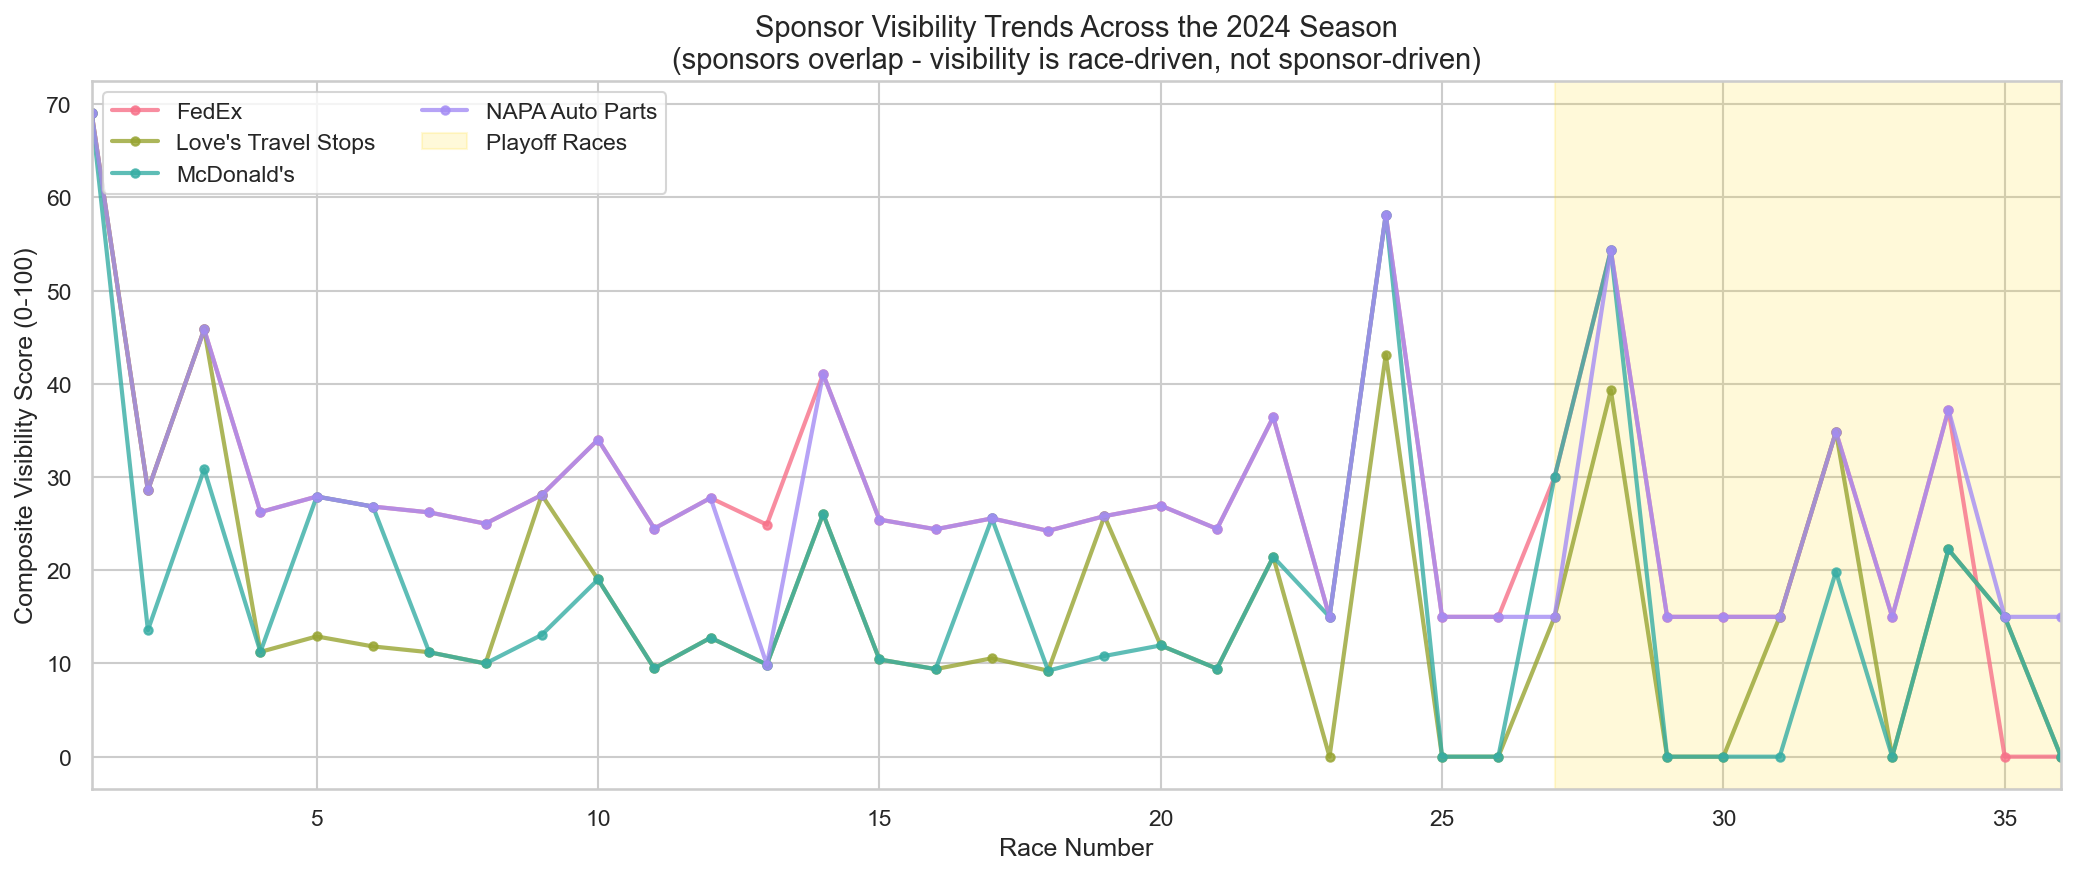

Saved line_visibility_trends.png


In [6]:
for ch in ['Reddit_Mentions', 'YouTube_Views', 'News_Mentions']:
    rng = df[ch].max() - df[ch].min()
    df[ch + '_n'] = 0.5 if rng == 0 else (df[ch] - df[ch].min()) / rng * 100
df['Visibility_Composite'] = (0.4*df['Reddit_Mentions_n'] + 0.3*df['YouTube_Views_n']
                              + 0.3*df['News_Mentions_n'])

fig, ax = plt.subplots(figsize=(14, 6))
for i, sponsor in enumerate(sponsors):
    sd = df[df['Sponsor'] == sponsor].sort_values('Race_Number')
    ax.plot(sd['Race_Number'], sd['Visibility_Composite'], marker='o', markersize=4,
            linewidth=2, alpha=0.8, color=colors[i], label=sponsor)
ax.axvspan(27, 36, alpha=0.15, color='gold', label='Playoff Races')
ax.set_xlabel('Race Number')
ax.set_ylabel('Composite Visibility Score (0-100)')
ax.set_title('Sponsor Visibility Trends Across the 2024 Season\n(sponsors overlap - visibility is race-driven, not sponsor-driven)')
ax.set_xlim(1, 36)
ax.legend(loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG}/line_visibility_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved line_visibility_trends.png')

### 4.3 Weekly exposure heatmap (Sponsor × Race)

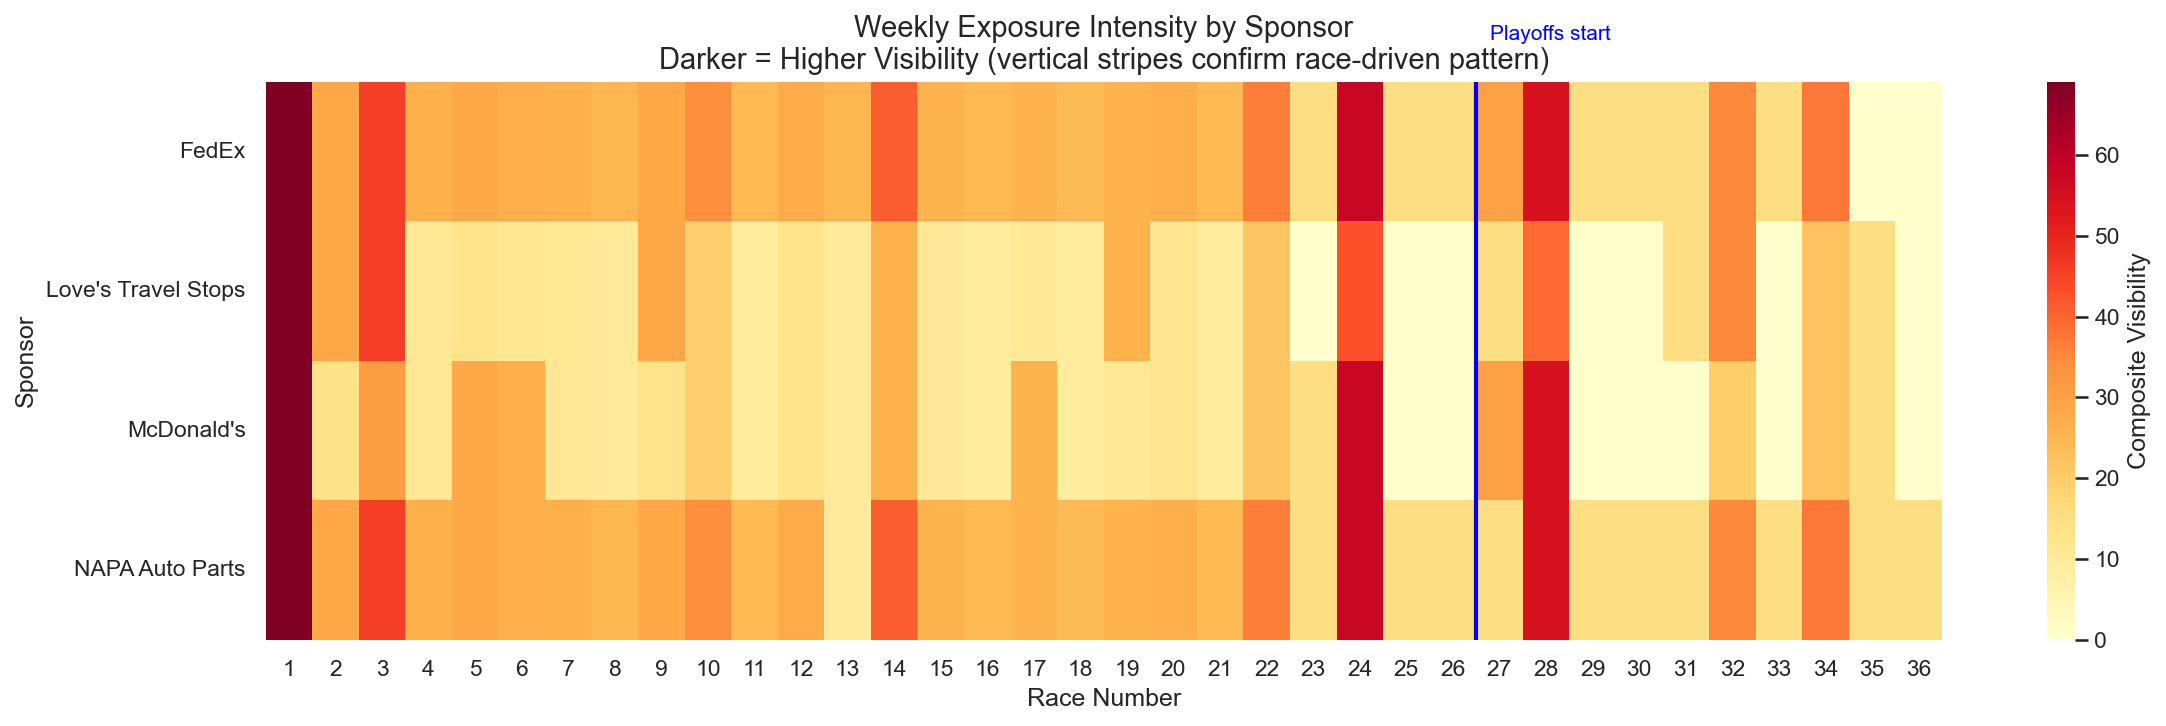

Saved heatmap_weekly_exposure.png


In [7]:
df['Week'] = df['Race_Number']
heatmap_data = df.pivot_table(values='Visibility_Composite', index='Sponsor',
                              columns='Week', aggfunc='mean').fillna(0)
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False,
            cbar_kws={'label': 'Composite Visibility'}, ax=ax)
ax.axvline(x=26, color='blue', linewidth=2)
ax.text(26.3, -0.3, 'Playoffs start', fontsize=10, color='blue')
ax.set_xlabel('Race Number')
ax.set_ylabel('Sponsor')
ax.set_title('Weekly Exposure Intensity by Sponsor\nDarker = Higher Visibility (vertical stripes confirm race-driven pattern)')
plt.tight_layout()
plt.savefig(f'{FIG}/heatmap_weekly_exposure.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved heatmap_weekly_exposure.png')

### 4.4 Channel mix - where does each sponsor's visibility come from? (stacked bar)

**Adaptation:** on raw magnitude, YouTube views (millions) are ~99.9% of every bar - an
uninformative chart. Instead we show each channel's **share of the composite visibility
score** (weighted, normalized). Because Reddit and YouTube are race-level (fixed across
sponsors), the *news* slice is what separates sponsors - bigger news share = more
sponsor-specific coverage.

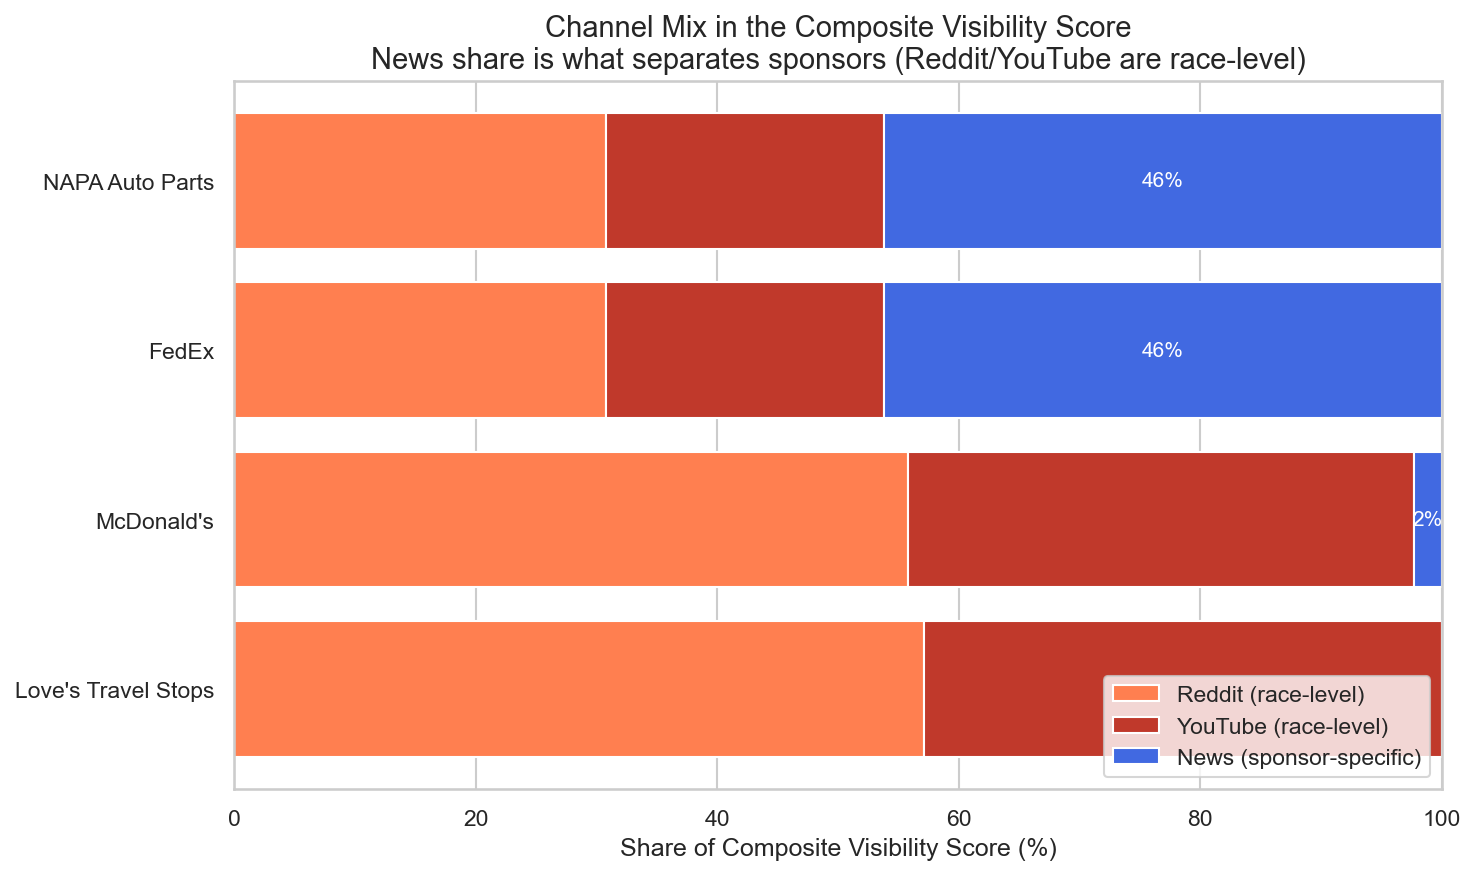

                     Reddit_Pct  YouTube_Pct  News_Pct
Sponsor                                               
Love's Travel Stops        57.1         42.9       0.0
McDonald's                 55.8         41.9       2.3
FedEx                      30.8         23.1      46.2
NAPA Auto Parts            30.8         23.1      46.2


In [8]:
contrib = pd.DataFrame(index=sponsor_summary.index)
contrib['Reddit'] = sponsor_summary['Reddit_N'] * 0.4 * 100
contrib['YouTube'] = sponsor_summary['YouTube_N'] * 0.3 * 100
contrib['News'] = sponsor_summary['News_N'] * 0.3 * 100
row_tot = contrib.sum(axis=1)
for c in ['Reddit', 'YouTube', 'News']:
    contrib[c + '_Pct'] = contrib[c] / row_tot * 100
contrib = contrib.sort_values('News_Pct')

fig, ax = plt.subplots(figsize=(10, 6))
sp = contrib.index
ax.barh(sp, contrib['Reddit_Pct'], label='Reddit (race-level)', color='#FF7F50')
ax.barh(sp, contrib['YouTube_Pct'], left=contrib['Reddit_Pct'], label='YouTube (race-level)', color='#C0392B')
ax.barh(sp, contrib['News_Pct'], left=contrib['Reddit_Pct']+contrib['YouTube_Pct'],
        label='News (sponsor-specific)', color='#4169E1')
for i, (name, row) in enumerate(contrib.iterrows()):
    if row['News_Pct'] > 2:
        ax.text(row['Reddit_Pct']+row['YouTube_Pct']+row['News_Pct']/2, i,
                f"{row['News_Pct']:.0f}%", va='center', ha='center', color='white', fontsize=10)
ax.set_xlabel('Share of Composite Visibility Score (%)')
ax.set_title("Channel Mix in the Composite Visibility Score\nNews share is what separates sponsors (Reddit/YouTube are race-level)")
ax.legend(loc='lower right')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig(f'{FIG}/stacked_channel_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print(contrib[['Reddit_Pct','YouTube_Pct','News_Pct']].round(1))

---
## Step 5, Hypothesis Testing

Transform the visual patterns into testable hypotheses and quantify each.

In [9]:
print('='*60)
print('HYPOTHESIS TESTS')
print('='*60)

# H1: Top-5 finishes vs P11+ social mentions
top5 = df[df['Finish_Position'] <= 5]['Reddit_Mentions'].mean()
outside = df[df['Finish_Position'] > 10]['Reddit_Mentions'].mean()
print(f'\nH1 Top-5 effect (Reddit):')
print(f' Top-5 finishes avg Reddit: {top5:.2f}')
print(f' P11+ finishes avg Reddit: {outside:.2f}')
print(f' Ratio: {top5/outside:.2f}x')

# also news (the sponsor-varying channel)
top5n = df[df['Finish_Position'] <= 5]['News_Mentions'].mean()
outn = df[df['Finish_Position'] > 10]['News_Mentions'].mean()
print(f' [News] Top-5: {top5n:.2f} vs P11+: {outn:.2f} -> {top5n/outn:.2f}x')

# H2: Wins vs non-wins total (composite) visibility
win_v = df[df['Finish_Position'] == 1]['Visibility_Composite'].mean()
nonwin_v = df[df['Finish_Position'] > 1]['Visibility_Composite'].mean()
print(f'\nH2 Win effect (composite visibility):')
print(f' Wins: {win_v:.2f} vs Non-wins: {nonwin_v:.2f} -> {win_v/nonwin_v:.2f}x')

# H3: Playoff vs regular
play = df[df['Race_Number'] >= 27]['Visibility_Composite'].mean()
reg = df[df['Race_Number'] < 27]['Visibility_Composite'].mean()
print(f'\nH3 Playoff effect:')
print(f' Playoff: {play:.2f} vs Regular: {reg:.2f} -> {(play/reg-1)*100:+.1f}%')

# H4: channel predictability (R^2 of finish vs each channel)
print(f'\nH4 Channel predictability from finish position (R-squared):')
for ch in ['Reddit_Mentions', 'YouTube_Views', 'News_Mentions']:
    r = df['Finish_Position'].corr(df[ch])
    print(f' {ch:16s}: r={r:+.3f} R2={r**2:.4f}')

# H1 significance test
from scipy.stats import ttest_ind
a = df[df['Finish_Position'] <= 5]['News_Mentions']
b = df[df['Finish_Position'] > 10]['News_Mentions']
t, pv = ttest_ind(a, b, equal_var=False)
print(f'\nH1 (news) t-test: t={t:.2f}, p={pv:.4f}')

HYPOTHESIS TESTS

H1 Top-5 effect (Reddit):
 Top-5 finishes avg Reddit: 6.94
 P11+ finishes avg Reddit: 7.80
 Ratio: 0.89x
 [News] Top-5: 0.84 vs P11+: 0.64 -> 1.31x

H2 Win effect (composite visibility):
 Wins: 26.66 vs Non-wins: 22.02 -> 1.21x

H3 Playoff effect:
 Playoff: 18.26 vs Regular: 23.64 -> -22.8%

H4 Channel predictability from finish position (R-squared):
 Reddit_Mentions : r=-0.024 R2=0.0006
 YouTube_Views   : r=+0.124 R2=0.0153
 News_Mentions   : r=-0.048 R2=0.0023

H1 (news) t-test: t=1.75, p=0.0845


### Save hypotheses & visualization-review markdown (feeds the EDA report)

In [10]:
import json
os.makedirs('../docs', exist_ok=True)
# nothing heavy here; the docs are authored separately. Export the key numbers as JSON
# so the EDA report builder can reuse them.
metrics = {
    'primary_scatter_r': round(df['Finish_Position'].corr(df['Reddit_Mentions']), 3),
    'h1_top5_reddit_ratio': round(top5/outside, 2),
    'h1_top5_news_ratio': round(top5n/outn, 2),
    'h2_win_ratio': round(win_v/nonwin_v, 2),
    'h3_playoff_pct': round((play/reg-1)*100, 1),
    'h4_r2': {ch: round(df['Finish_Position'].corr(df[ch])**2, 4)
              for ch in ['Reddit_Mentions','YouTube_Views','News_Mentions']},
    'sponsor_visibility': sponsor_summary['Visibility_Score'].to_dict(),
}
with open('../data/processed/eda_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved eda_metrics.json'); print(json.dumps(metrics, indent=2))

Saved eda_metrics.json
{
  "primary_scatter_r": -0.024,
  "h1_top5_reddit_ratio": 0.89,
  "h1_top5_news_ratio": 1.31,
  "h2_win_ratio": 1.21,
  "h3_playoff_pct": -22.8,
  "h4_r2": {
    "Reddit_Mentions": 0.0006,
    "YouTube_Views": 0.0153,
    "News_Mentions": 0.0023
  },
  "sponsor_visibility": {
    "Love's Travel Stops": 35.0,
    "McDonald's": 35.8,
    "FedEx": 65.0,
    "NAPA Auto Parts": 65.0
  }
}
